# Transformer for Temperature Prediction

This notebook builds, trains, and evaluates the Transformer counterpart to the team's LSTM baseline for the DAAN 570 course project (Temperature Prediction with Deep Learning).

**Task**: predict `temperature_2m` `FORECAST_HORIZON` hours ahead, given the previous `WINDOW_SIZE` hours of weather features for a given city.

This notebook is self-contained: it loads data, explains and builds the Transformer architecture step by step, trains it (or loads an already-trained result if one matching the current configuration exists — see the "Train or load" section below), evaluates it, and compares it against the LSTM baseline.

*This notebook assumes you're comfortable with general neural network ideas (layers, weights, training, loss, dropout) but explains every Transformer-specific concept from scratch, using plain-language analogies before the technical vocabulary.*

## Data

The `data/splits/{train,dev,test}.csv` files used below are derived from `data/raw/*.csv` (one file per city, tracked via Git LFS so both of us train on the exact same rows) via `src/data/preprocess.py` -> `src/data/split_dataset.py` (chronological 70/15/15 split per city). `data.load_splits()` regenerates `data/splits/` automatically if it's missing (fast, ~20s, fully deterministic) -- so the first run after a fresh clone (or `git lfs pull`) may take a few extra seconds the first time.

The raw CSVs themselves came from the Open-Meteo Archive API for the 16 cities in `src/utils/city_coordinates.py`, 2015-01-01 to 2024-12-31 -- that fetch step is not re-run here, since it's slow (rate-limited) and only needs to happen once per city, ever.

In [1]:
import sys
from pathlib import Path


def find_project_root(marker="weather_main.py"):
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root (looking for {marker})")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers

from src.models.transformer import architecture
from src.models.common import data
from src.models.transformer.training import TransformerConfig, run_training, load_cached_results, timestamp_now
from src.models.common.compare import find_cached_experiment, compare
from src.models.common.plotting import plot_loss_curve, plot_mae_curve, plot_prediction_curve

In [3]:
train_df, dev_df, test_df = data.load_splits()

print("Train rows:", len(train_df))
print("Dev rows  :", len(dev_df))
print("Test rows :", len(test_df))
train_df.head()

Train rows: 981920
Dev rows  : 210416
Test rows : 210416


,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,cloud_cover,precipitation,is_day,city,year,month,day,hour,day_of_week,day_of_year,hour_sin,hour_cos,day_sin,day_cos
0,2015-01-01 00:00:00,5.5,67.0,988.900024,7.4,1.0,0.0,0.0,atlanta.csv,2015,1,1,0,3,1,0.000000,1.000000,0.017213,0.999852
1,2015-01-01 01:00:00,4.4,66.0,988.900024,7.3,0.0,0.0,0.0,atlanta.csv,2015,1,1,1,3,1,0.258819,0.965926,0.017213,0.999852
2,2015-01-01 02:00:00,3.5,66.0,988.700012,6.0,53.0,0.0,0.0,atlanta.csv,2015,1,1,2,3,1,0.500000,0.866025,0.017213,0.999852
3,2015-01-01 03:00:00,2.7,66.0,989.000000,6.0,38.0,0.0,0.0,atlanta.csv,2015,1,1,3,3,1,0.707107,0.707107,0.017213,0.999852
4,2015-01-01 04:00:00,2.0,67.0,988.700012,6.6,30.0,0.0,0.0,atlanta.csv,2015,1,1,4,3,1,0.866025,0.500000,0.017213,0.999852


## Configuration

Every hyperparameter lives here, in one place. Changing anything below and re-running the notebook will train a fresh model automatically (see "Train or load" section) -- the cached result only gets reused when the configuration matches exactly.

In [4]:
CONFIG = TransformerConfig(
    window_size=24,
    forecast_horizon=3,
    d_model=64,
    num_heads=4,
    num_encoder_layers=2,
    ff_dim=128,
    dropout_rate=0.20,
    batch_size=32,
    epochs=25
)

FORCE_RETRAIN = False  # set True to ignore any cached result and retrain regardless

CONFIG

TransformerConfig(window_size=24, forecast_horizon=3, d_model=64, num_heads=4, num_encoder_layers=2, ff_dim=128, dropout_rate=0.2, batch_size=32, epochs=25)

## Why a Transformer, and why this architecture

Think about how the LSTM reads our 24-hour window: one hour at a time, left to right, updating a running "summary" (its hidden state) as it goes. By the time it reaches hour 24, whatever happened at hour 1 has been squeezed through 23 rounds of summarizing -- like a game of telephone, some of it fades.

A Transformer encoder does something different: **every hour looks at every other hour directly, all at once**, in a single step -- no passing information down a chain. This is called **self-attention**, and we'll unpack exactly how it works below.

We use an **encoder-only** Transformer -- no decoder. A decoder exists to *generate* a sequence one piece at a time (like translating a sentence word by word). We don't need that here: we just need to look at the 24-hour window once and output a single number. So we only need the "look at everything and understand it" half of a Transformer, not the "generate output step by step" half.

*In precise terms: encoder-only architecture, self-attention instead of recurrence, built for a single-output regression task rather than sequence generation.*

The building blocks below (`positional_encoding`, `transformer_encoder_block`) are imported from `src/models/transformer/architecture.py` -- the exact same code the standalone training script (`model.py`) uses, so there's no risk of the explanation here drifting from what's actually trained.

In [5]:
X_train, y_train = data.create_sequences(train_df, CONFIG.window_size, CONFIG.forecast_horizon)
X_dev, y_dev = data.create_sequences(dev_df, CONFIG.window_size, CONFIG.forecast_horizon)
X_test, y_test = data.create_sequences(test_df, CONFIG.window_size, CONFIG.forecast_horizon)

print("X_train shape:", X_train.shape)
print("X_dev shape  :", X_dev.shape)
print("X_test shape :", X_test.shape)

X_train shape: (981894, 24, 10)
X_dev shape  : (210390, 24, 10)
X_test shape : (210390, 24, 10)


### Positional encoding

Here's a subtlety: self-attention, as just described, looks at "every hour" but has no built-in sense of *which* hour is which. If you handed someone 24 index cards of hourly weather data, shuffled into a random pile, self-attention would treat that shuffled pile identically to the cards in proper order -- it just sees 24 things, with no notion of sequence. That's a real problem for weather, where "3 hours ago" vs. "20 hours ago" matters a lot.

The fix: before anything else happens, we stamp each of the 24 positions with a unique numeric "tag" -- a pattern of numbers that's different for position 0, different again for position 1, and so on, all the way to position 23. Think of it like giving each index card a unique barcode based on its place in the pile, so even after self-attention mixes information around, the model can still tell which hour contributed what.

The actual tags come from a fixed pattern of sine and cosine waves (one of several ways researchers have designed this -- this is the original scheme from the 2017 paper that introduced Transformers). You don't need to memorize the formula; what matters is that it produces a unique, consistent fingerprint per position, and it's fixed math, not something the model learns.

**Don't confuse this with `hour_sin`/`hour_cos` from our input features** -- those describe *time of day* (is it 3am or 3pm?), a genuine weather-relevant signal. Positional encoding describes *where in this specific 24-hour window* a row sits (is it the oldest hour or the most recent?) -- a purely structural bookkeeping detail, added by the architecture, not the data.

*In precise terms: fixed sinusoidal positional encoding (Vaswani et al., 2017), added elementwise to the input embeddings before the first attention layer, since self-attention is otherwise permutation-invariant.*

In [6]:
pe = architecture.positional_encoding(CONFIG.window_size, CONFIG.d_model)
print("Positional encoding shape:", pe.shape)

Positional encoding shape: (24, 64)


### Multi-head self-attention, and why the model stays modest

Picture 24 people standing in a line, one per hour in our window. Self-attention lets every person turn and look at *all 23 others at once* (including themselves) and silently ask: "how relevant are you to figuring out what I should become?" Based on the answers, each person blends together a bit of everyone's information -- weighted much more heavily toward whoever seemed most relevant, and barely at all toward whoever seemed irrelevant.

Mechanically, this "how relevant are you" question has a name: each hour produces a **Query** (what am I looking for?), and compares it against every other hour's **Key** (what do I have to offer?). A close match between a Query and a Key produces a high relevance score. Those scores get turned into weights, and each hour then collects a weighted blend of everyone's **Value** (the actual content being shared) using those weights. It's a bit like a room where everyone asks a question out loud (Query), listens to how well each other person's "advertisement" (Key) answers it, and then actually listens most closely to whoever had the best match (Value).

We don't just do this once -- we do it **4 times in parallel** ("4 heads"), each with its own separate Queries/Keys/Values. Think of it as 4 separate small committees looking at the same 24 hours, each free to focus on a different kind of relationship (one might latch onto "which hour is closest to right now," another onto "which hour had the biggest jump in humidity"). Their 4 separate conclusions get stitched back together at the end.

After attention mixes information across hours, two more ideas keep training stable:
- **Residual connection**: we keep a copy of the input around and *add* attention's output to it, rather than replacing it outright. Analogy: instead of throwing away your notes and rewriting from scratch, you keep your original notes and jot corrections in the margin. This makes it much easier for the network to learn small, useful adjustments instead of having to reconstruct everything from nothing, and it helps gradients flow cleanly through a stack of layers during training.
- **Layer normalization**: after combining things, we rescale each hour's numbers back to a consistent, well-behaved range -- similar to normalizing a photo's brightness/contrast before passing it to the next step, so nothing downstream gets thrown off by numbers that have grown too large or too small.

Then there's a second, smaller step in each block: a **feed-forward sub-layer** -- a tiny 2-layer network applied to *each hour separately* (not mixing across hours anymore; that already happened in attention). Think of it as each person, after hearing what everyone else in the room had to say, taking a quiet moment alone to process it before moving on. Same residual-connection-plus-rescaling pattern wraps around this step too.

One "block" = attention (with its residual+rescale) followed by feed-forward (with its own residual+rescale). We stack **2 of these blocks**, so the whole room-of-24-people conversation effectively happens twice, each time refining everyone's understanding further.

**Why keep it small** (`d_model=64`, only 4 heads, only 2 blocks)? Roughly matching the LSTM's own width (`LSTM(64, ...)`) keeps the comparison fair, and Transformers tend to overfit more easily than LSTMs on a dataset this size unless you deliberately hold capacity back -- so we're not scaling this up just because we can.

*In precise terms: scaled dot-product multi-head self-attention (4 heads, key_dim=16) with a residual connection and layer normalization, followed by a position-wise feed-forward sub-layer (Dense(128, relu) -> Dense(64)) with its own residual connection and layer normalization -- the standard Transformer encoder block, stacked twice.*

In [7]:
dummy_batch = tf.random.normal((2, CONFIG.window_size, CONFIG.d_model))
dummy_out = architecture.transformer_encoder_block(
    dummy_batch, CONFIG.d_model, CONFIG.num_heads, CONFIG.ff_dim, CONFIG.dropout_rate
)
print("Encoder block output shape:", dummy_out.shape)

Encoder block output shape: (2, 24, 64)


### Assembling the full model

Input -> per-timestep normalization -> project the 10 raw features up to `d_model` dimensions -> add positional encoding -> `num_encoder_layers` encoder blocks -> pool across the 24 timesteps -> small dense head -> single scalar prediction.

After 2 encoder blocks, we have a refined 64-number summary *for each of the 24 hours* -- but we only need to output one prediction for the whole window, not 24. `GlobalAveragePooling1D` handles this by simply averaging all 24 hourly summaries together into one 64-number summary of the whole window, the way you might average 24 people's individual opinions into one final group verdict.

This is written out explicitly here (rather than calling one `build_model(...)` function) so every step is visible. It mirrors `architecture.build_model()` line-for-line -- that function is what the CLI training script (`model.py`) always uses, so this notebook and the script can never silently diverge.

In [8]:
normalizer = layers.Normalization()
normalizer.adapt(X_train.reshape(-1, X_train.shape[-1]))

inputs = tf.keras.Input(shape=(CONFIG.window_size, X_train.shape[-1]), name="weather_sequence")

x = layers.TimeDistributed(normalizer)(inputs)
x = layers.Dense(CONFIG.d_model)(x)
x = x + architecture.positional_encoding(CONFIG.window_size, CONFIG.d_model)

for _ in range(CONFIG.num_encoder_layers):
    x = architecture.transformer_encoder_block(
        x, CONFIG.d_model, CONFIG.num_heads, CONFIG.ff_dim, CONFIG.dropout_rate
    )

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(CONFIG.dropout_rate)(x)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1, name="temperature_prediction")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ weather_sequence    │ (None, 24, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 24, 10)    │         21 │ weather_sequence… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 24, 64)    │        704 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 24, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 24, 64)    │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 24, 64)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 24, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 24, 64)    │      8,256 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 24, 64)    │          0 │ dense_6[0][0]   

 Total params: 70,294 (274.59 KB)

 Trainable params: 70,273 (274.50 KB)

 Non-trainable params: 21 (88.00 B)

## Train or load

Training on the full dataset takes real time (this repo's earlier full CLI run took ~40 minutes on a CPU-only machine before early stopping kicked in). To keep this notebook fast to re-run while writing the report, it only actually trains if **no previous experiment used this exact `CONFIG`** -- otherwise it loads that experiment's already-saved results. Set `FORCE_RETRAIN = True` above to bypass this and retrain regardless.

**Important**: a config match means we already tried this exact hyperparameter combination -- it does not mean re-running it would reproduce identical numbers. Random weight initialization and dropout mean two runs of the same configuration can land on slightly different `val_loss` / stop at a different epoch.

In [ ]:
MODEL_ROOT = data.PROJECT_ROOT / "models" / "Transformer" / "baseline"
checkpoint_path = MODEL_ROOT / "checkpoints" / "best.keras"

config_dict = CONFIG.to_dict()
cached_dir = None if FORCE_RETRAIN else find_cached_experiment("Transformer/baseline", config_dict)

if cached_dir:
    print(f"Found a cached experiment matching this config: {cached_dir.name}")
    print("Loading its saved results (set FORCE_RETRAIN=True above to retrain anyway).")
    results = load_cached_results(cached_dir)
else:
    print("No cached experiment matches this config (or FORCE_RETRAIN=True) -- training now...")
    experiment_dir = MODEL_ROOT / "experiments" / timestamp_now()
    results = run_training(CONFIG, experiment_dir, checkpoint_path, model=model, show_plots=True)

print("Experiment dir:", results["experiment_dir"])

## Results

Test Loss : 18.8975
Test MAE  : 3.5342
Test RMSE : 4.3471
Epochs trained: 12


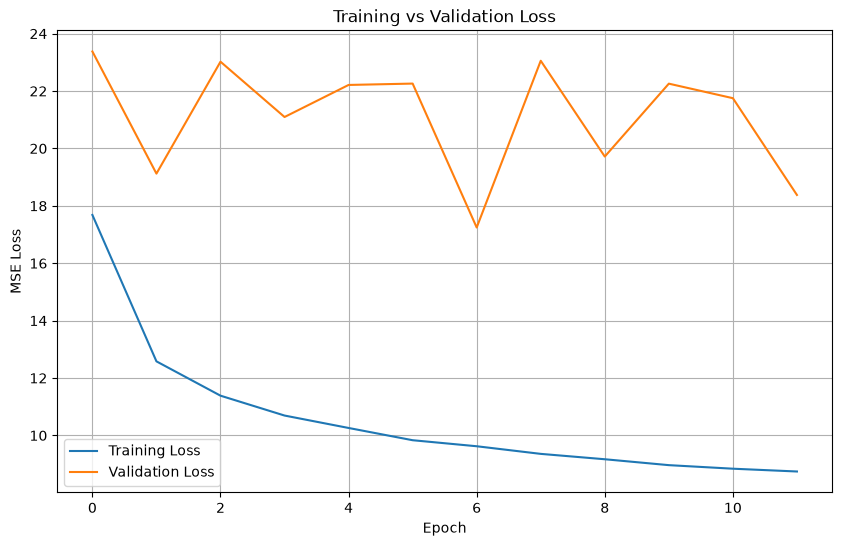

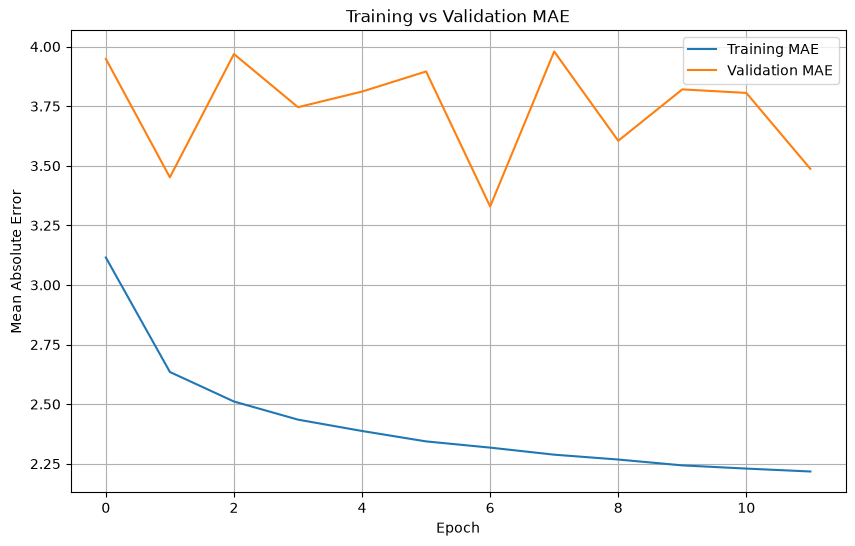

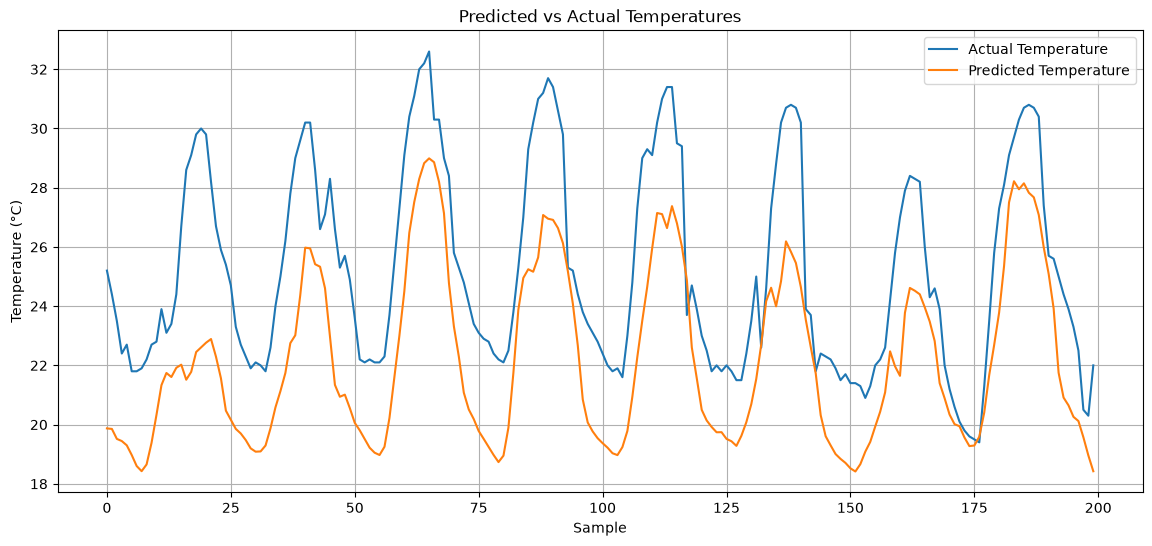

,Actual,Predicted,Error
0,25.2,19.871141,-5.328859
1,24.4,19.853294,-4.546705
2,23.5,19.516830,-3.983170
3,22.4,19.443615,-2.956385
4,22.7,19.299942,-3.400059
5,21.8,18.973019,-2.826981
6,21.8,18.600182,-3.199818
7,21.9,18.425932,-3.474068
8,22.2,18.653822,-3.546179
9,22.7,19.382557,-3.317444


In [10]:
print(f"Test Loss : {results['loss']:.4f}")
print(f"Test MAE  : {results['mae']:.4f}")
print(f"Test RMSE : {results['rmse']:.4f}")
print(f"Epochs trained: {results['epochs_trained']}")

figure_dir = results["experiment_dir"] / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

plot_loss_curve(results["history"], figure_dir, show=True)
plot_mae_curve(results["history"], figure_dir, show=True)
plot_prediction_curve(results["y_test"], results["predictions"], figure_dir, show=True)

pd.read_csv(results["experiment_dir"] / "predictions.csv").head(10)

## Comparison to the LSTM baseline

Reuses `src/models/common/compare.py` as-is -- it finds each model's most recent experiment with a `metrics.json` and builds a side-by-side table + chart under its own subfolder in `models/comparison/`, named after the models compared (so different comparisons never overwrite each other). See `compare_all()` for a combined view across every trained model.

In [ ]:
compare()

------------------------------------------------------------
Model Comparison
------------------------------------------------------------
               model          experiment     loss      mae     rmse  epochs_trained
                LSTM 2026-07-01_17-14-36 13.11574 2.804011 3.621566              18
Transformer/baseline 2026-07-17_19-36-12 18.89748 3.534157 4.347123              12
------------------------------------------------------------
Saved to: /Users/maartenhandels/Desktop/GitHub/LarryGreen-alt/Temperature_Prediction_DeepLearning/models/comparison/LSTM_vs_Transformer-baseline/comparison.csv
Saved chart to: /Users/maartenhandels/Desktop/GitHub/LarryGreen-alt/Temperature_Prediction_DeepLearning/models/comparison/LSTM_vs_Transformer-baseline/comparison_chart.png


## Caveats & discussion

- **Data provenance**: `data/raw/` is now committed via Git LFS, so this comparison and every future one will run on the exact same rows for both of us. The one exception is the LSTM result already sitting in `models/LSTM/experiments/` -- that was trained before this raw data was fixed and version-controlled, so it isn't guaranteed to be on byte-identical rows to what's committed now. A re-run of the LSTM against today's committed `data/raw/` would close that gap fully.
- **`checkpoints/best.keras` is not "best across all runs"**: Keras resets `ModelCheckpoint`'s internal best-value tracker to infinity at the start of every `fit()` call, so a new run's very first epoch always overwrites that file -- regardless of whether it's actually better than what a previous run had saved there. The durable, comparable record is each experiment's own `metrics.json` under `models/<Model>/experiments/<timestamp>/`, not the shared checkpoint file.
- **Framework/horizon vs. the original proposal**: the course proposal document described PyTorch and a 24-hour forecast horizon; both models actually use Keras/TensorFlow and a 3-hour horizon, matching what the LSTM was actually built and evaluated on. This was a deliberate, documented team decision to keep the comparison apples-to-apples, not an oversight.
- **A result, not necessarily the final word**: as trained here, this Transformer configuration is outperformed by the LSTM baseline on MAE/RMSE. Given the short (24-hour) window, the strongly periodic/autocorrelated target (3 hours ahead), and the modest capacity chosen to control overfitting, this isn't unexpected -- self-attention tends to earn its keep on longer, more complex dependencies than recurrence doesn't already capture well. Trying larger/smaller configurations via `CONFIG` above is a natural next step.

*(This section is intentionally short -- trim or expand freely for the final report.)*